In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)


In [2]:

# -----------------------------------------------------------
# 0. Chargement du dataset labellisé (issu de l'étape 3)
# -----------------------------------------------------------
df_final = pd.read_csv('../data/processed/labeled_data.csv')
print("Shape:", df_final.shape)
df_final.head()

Shape: (523844, 12)


,ERY,HK,LEUKO,HB,PLT,MCV,MCHC,MCH,RDW,anomaly_score,weighted_score,label
0,4.5,40.7,8.5,13.7,154,90.4,33.7,30.4,13.2,0,0,0
1,4.2,36.8,11.8,12.9,255,87.4,35.1,30.6,12.7,2,4,0
2,4.3,37.4,8.5,12.7,310,86.4,33.9,29.3,13.0,0,0,0
3,4.3,36.4,7.7,13.3,221,84.4,36.6,30.9,13.1,2,2,0
4,4.1,37.1,10.8,12.3,198,91.3,33.2,30.3,13.5,1,3,0


In [3]:
# -----------------------------------------------------------
# 1. Définir y (identique pour les deux expériences)
# -----------------------------------------------------------
y = df_final['label']

print("Distribution de y (proportions):")
print(y.value_counts(normalize=True))

Distribution de y (proportions):
label
0    0.713802
1    0.286198
Name: proportion, dtype: float64


In [4]:
# -----------------------------------------------------------
# 2. Définir les deux jeux de features
# -----------------------------------------------------------

# Expérience A — toutes les variables (sanity check / data leakage total)
features_A = ['ERY', 'HK', 'LEUKO', 'HB', 'PLT', 'MCV', 'MCHC', 'MCH', 'RDW']

# Expérience B1 — uniquement les variables à poids=1 (problème réaliste)
features_B1 = ['HK', 'MCV', 'MCHC', 'MCH', 'RDW']

X_A = df_final[features_A]
X_B1 = df_final[features_B1]

print("Shape X_A  (Expérience A) :", X_A.shape)
print("Shape X_B1 (Expérience B1):", X_B1.shape)

Shape X_A  (Expérience A) : (523844, 9)
Shape X_B1 (Expérience B1): (523844, 5)


In [5]:
# -----------------------------------------------------------
# 3. Fonction réutilisable : split + scaling
# -----------------------------------------------------------
def prepare_train_test(X, y, feature_names, experiment_name, test_size=0.2, random_state=42):
    """
    Split stratifié + normalisation (fit sur train uniquement).
    Retourne X_train_scaled, X_test_scaled, y_train, y_test, scaler.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test), columns=feature_names, index=X_test.index
    )

    print(f"\n--- {experiment_name} ---")
    print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)
    print("Distribution y_train:", y_train.value_counts(normalize=True).to_dict())
    print("Distribution y_test :", y_test.value_counts(normalize=True).to_dict())

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

In [6]:
# -----------------------------------------------------------
# 4. Préparation Expérience A (9 features)
# -----------------------------------------------------------
X_train_A, X_test_A, y_train_A, y_test_A, scaler_A = prepare_train_test(
    X_A, y, features_A, "Expérience A (9 features — sanity check)"
)


--- Expérience A (9 features — sanity check) ---
Train shape: (419075, 9) | Test shape: (104769, 9)
Distribution y_train: {0: 0.7138030185527651, 1: 0.286196981447235}
Distribution y_test : {0: 0.713798929072531, 1: 0.286201070927469}


In [7]:
# -----------------------------------------------------------
# 5. Préparation Expérience B1 (5 features)
# -----------------------------------------------------------
X_train_B1, X_test_B1, y_train_B1, y_test_B1, scaler_B1 = prepare_train_test(
    X_B1, y, features_B1, "Expérience B1 (5 features — problème réaliste)"
)


--- Expérience B1 (5 features — problème réaliste) ---
Train shape: (419075, 5) | Test shape: (104769, 5)
Distribution y_train: {0: 0.7138030185527651, 1: 0.286196981447235}
Distribution y_test : {0: 0.713798929072531, 1: 0.286201070927469}


In [8]:
# -----------------------------------------------------------
# 6. Sauvegarde des deux jeux de données préparés
# -----------------------------------------------------------

# Expérience A
X_train_A.to_csv('../data/processed/X_train_A.csv', index=False)
X_test_A.to_csv('../data/processed/X_test_A.csv', index=False)
y_train_A.to_csv('../data/processed/y_train_A.csv', index=False)
y_test_A.to_csv('../data/processed/y_test_A.csv', index=False)
joblib.dump(scaler_A, '../models/scaler_A.pkl')

# Expérience B1
X_train_B1.to_csv('../data/processed/X_train_B1.csv', index=False)
X_test_B1.to_csv('../data/processed/X_test_B1.csv', index=False)
y_train_B1.to_csv('../data/processed/y_train_B1.csv', index=False)
y_test_B1.to_csv('../data/processed/y_test_B1.csv', index=False)
joblib.dump(scaler_B1, '../models/scaler_B1.pkl')

print("✅ Données des 2 expériences sauvegardées dans data/processed/")
print("✅ Scalers sauvegardés dans models/")

✅ Données des 2 expériences sauvegardées dans data/processed/
✅ Scalers sauvegardés dans models/


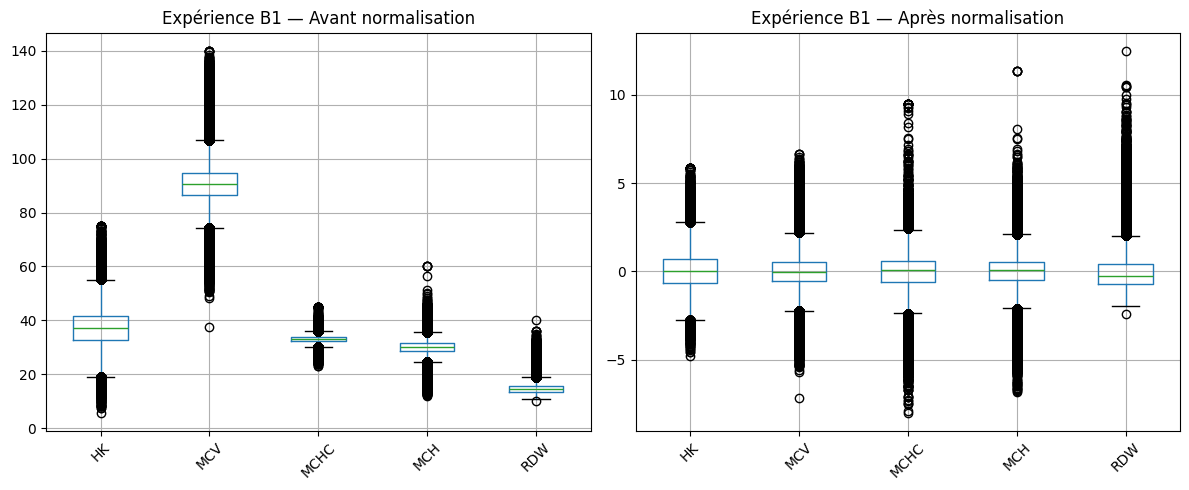

In [9]:
# -----------------------------------------------------------
# 7. Visualisation comparative avant/après scaling (Expérience B1)
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

X_B1.boxplot(ax=axes[0])
axes[0].set_title('Expérience B1 — Avant normalisation')
axes[0].tick_params(axis='x', rotation=45)

X_train_B1.boxplot(ax=axes[1])
axes[1].set_title('Expérience B1 — Après normalisation')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/scaling_experience_B1.png', dpi=150)
plt.show()

In [10]:
# -----------------------------------------------------------
# 8. Récapitulatif final des deux jeux de données
# -----------------------------------------------------------
print("=" * 60)
print("RÉCAPITULATIF DES DEUX EXPÉRIENCES")
print("=" * 60)
print(f"""
Expérience A  : {len(features_A)} features {features_A}
              → Train: {X_train_A.shape}, Test: {X_test_A.shape}
              → Data leakage: TOTAL (toutes les variables du label sont features)
              → Objectif: valider le pipeline ML (sanity check)

Expérience B1 : {len(features_B1)} features {features_B1}
              → Train: {X_train_B1.shape}, Test: {X_test_B1.shape}
              → Data leakage: RÉDUIT (variables à poids fort exclues des features)
              → Objectif: évaluer une vraie capacité de généralisation
""")

RÉCAPITULATIF DES DEUX EXPÉRIENCES

Expérience A  : 9 features ['ERY', 'HK', 'LEUKO', 'HB', 'PLT', 'MCV', 'MCHC', 'MCH', 'RDW']
              → Train: (419075, 9), Test: (104769, 9)
              → Data leakage: TOTAL (toutes les variables du label sont features)
              → Objectif: valider le pipeline ML (sanity check)

Expérience B1 : 5 features ['HK', 'MCV', 'MCHC', 'MCH', 'RDW']
              → Train: (419075, 5), Test: (104769, 5)
              → Data leakage: RÉDUIT (variables à poids fort exclues des features)
              → Objectif: évaluer une vraie capacité de généralisation

